In [1]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [2]:
# ==============================================
# CREDIT CARD FRAUD DETECTION - XGBOOST MODEL (FINAL)
# ==============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    RocCurveDisplay, PrecisionRecallDisplay   # 👈 Added here
)
from xgboost import XGBClassifier
import joblib
import warnings
warnings.filterwarnings('ignore')



In [3]:
# -------------------------
# 1. Load Dataset

# -------------------------
df = pd.read_csv('creditcard.csv')
print("✅ Dataset loaded successfully!")
print("Shape:", df.shape)
print(df['Class'].value_counts())


✅ Dataset loaded successfully!
Shape: (284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64


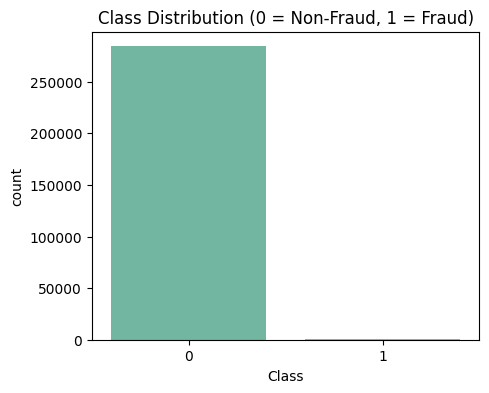


🔹 Class Value Counts:
Class
0    284315
1       492
Name: count, dtype: int64


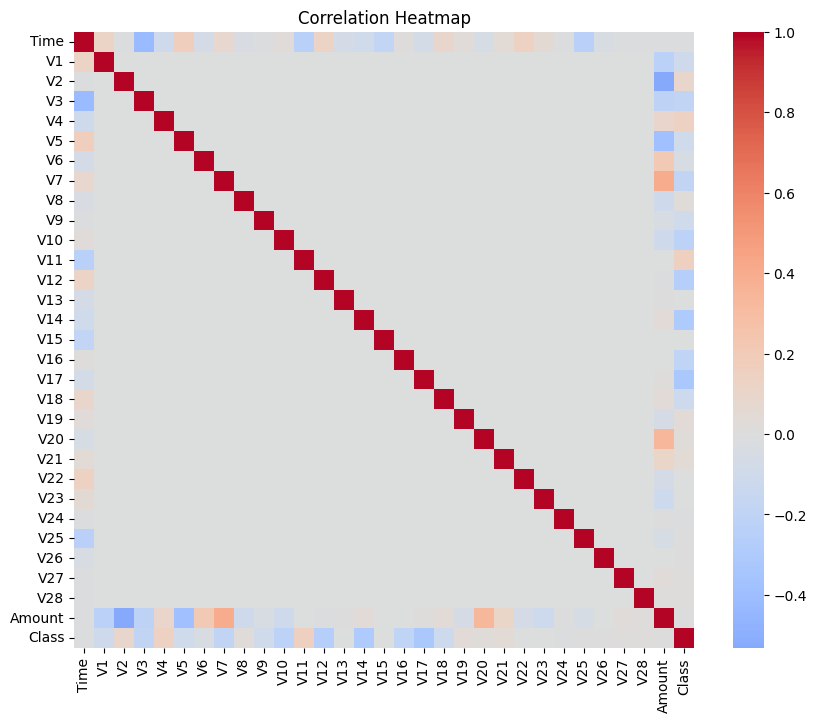

In [4]:
# -------------------------
# Data Exploration (NEW)
# -------------------------

# 2. Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()


In [5]:
# -------------------------
# 2. Data Preprocessing
# -------------------------
X = df.drop('Class', axis=1)
y = df['Class']

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print("\nData split complete:")
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Class distribution in train:\n", y_train.value_counts())



Data split complete:
Train shape: (227845, 30) Test shape: (56962, 30)
Class distribution in train:
 Class
0    227451
1       394
Name: count, dtype: int64


In [6]:
# -------------------------
# 3. Define and Train XGBoost
# -------------------------
xgb_model = XGBClassifier(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]),  # imbalance handling
    eval_metric='logloss',
    random_state=42,
    use_label_encoder=False,
    n_jobs=-1
)

print("\n🚀 Training XGBoost model...")
xgb_model.fit(X_train, y_train)
print("✅ Training complete!")



🚀 Training XGBoost model...
✅ Training complete!


In [7]:
# -------------------------
# 4. Evaluate Model
# -------------------------
y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]

# Metrics
train_acc = accuracy_score(y_train, xgb_model.predict(X_train))
test_acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("\n✅ XGBoost Results:")
print(f"Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")
print(f"Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")

# Overfitting / Underfitting detection
if train_acc - test_acc > 0.05:
    print("⚠️ Possible Overfitting!")
elif train_acc < 0.8 and test_acc < 0.8:
    print("⚠️ Possible Underfitting!")
else:
    print("✅ Good Generalization!")



✅ XGBoost Results:
Train Acc: 1.0000 | Test Acc: 0.9995
Precision: 0.8723 | Recall: 0.8367 | F1: 0.8542 | AUC: 0.9699
✅ Good Generalization!


In [8]:
# -------------------------
# Detailed Classification Report (NEW)
# -------------------------
from sklearn.metrics import classification_report

print("\n📋 Detailed Classification Report:")
print(classification_report(y_test, y_pred, digits=4))



📋 Detailed Classification Report:
              precision    recall  f1-score   support

           0     0.9997    0.9998    0.9998     56864
           1     0.8723    0.8367    0.8542        98

    accuracy                         0.9995     56962
   macro avg     0.9360    0.9183    0.9270     56962
weighted avg     0.9995    0.9995    0.9995     56962



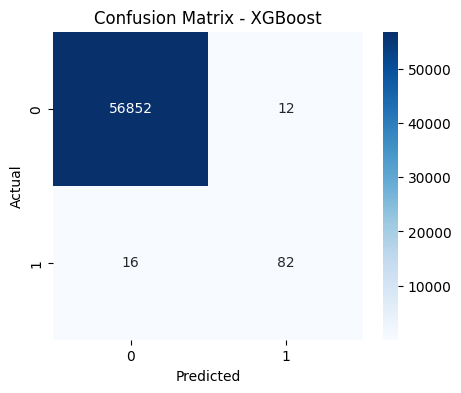

In [9]:
# -------------------------
# 5. Confusion Matrix
# -------------------------
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


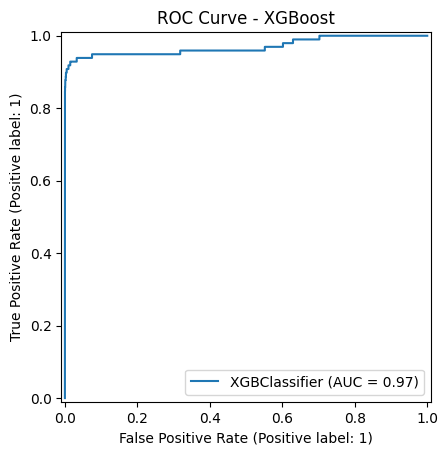

In [10]:
# -------------------------
# 6. ROC Curve
# -------------------------
RocCurveDisplay.from_estimator(xgb_model, X_test, y_test)
plt.title('ROC Curve - XGBoost')
plt.show()


In [11]:
# ==============================================
# EXPORT XGBOOST MODEL PERFORMANCE CHARTS
# ==============================================

import os
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

# Create a folder named 'xgboost_charts' if not already there
os.makedirs("xgboost_charts", exist_ok=True)

print("💾 Exporting all XGBoost charts to /xgboost_charts folder...")

# 1️⃣ Confusion Matrix
plt.figure(figsize=(5,4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig("xgboost_charts/confusion_matrix.png", dpi=300)
plt.close()

# 2️⃣ ROC Curve
plt.figure()
RocCurveDisplay.from_estimator(xgb_model, X_test, y_test)
plt.title('ROC Curve - XGBoost')
plt.tight_layout()
plt.savefig("xgboost_charts/roc_curve.png", dpi=300)
plt.close()

# 3️⃣ Precision–Recall Curve
plt.figure()
PrecisionRecallDisplay.from_estimator(xgb_model, X_test, y_test)
plt.title('Precision–Recall Curve - XGBoost')
plt.tight_layout()
plt.savefig("xgboost_charts/precision_recall_curve.png", dpi=300)
plt.close()

# 4️⃣ Train vs Test Accuracy
plt.figure(figsize=(4,4))
plt.bar(['Train Accuracy', 'Test Accuracy'], [train_acc, test_acc], color=['#4c72b0','#55a868'])
plt.title('Train vs Test Accuracy - XGBoost')
plt.ylim(0.8, 1.0)
plt.tight_layout()
plt.savefig("xgboost_charts/train_vs_test_accuracy.png", dpi=300)
plt.close()

# 5️⃣ Performance Metrics (Accuracy, Precision, Recall, F1)
metrics = {'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
           'Score': [test_acc, prec, rec, f1]}
metrics_df = pd.DataFrame(metrics)

plt.figure(figsize=(6,4))
sns.barplot(x='Metric', y='Score', data=metrics_df, palette='Blues_d')
plt.title('Model Performance Metrics - XGBoost')
plt.ylim(0,1)
plt.tight_layout()
plt.savefig("xgboost_charts/performance_metrics.png", dpi=300)
plt.close()

print("✅ All XGBoost performance charts exported successfully!")


💾 Exporting all XGBoost charts to /xgboost_charts folder...
✅ All XGBoost performance charts exported successfully!


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

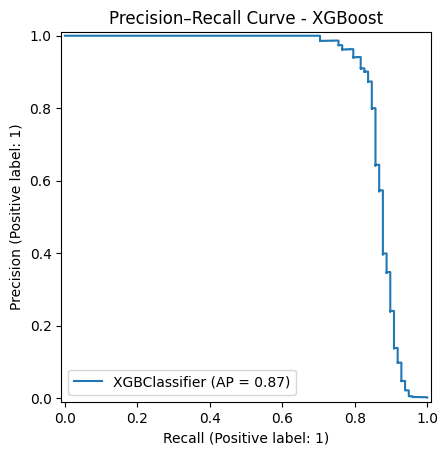

In [12]:
# -------------------------
# Precision–Recall Curve
# -------------------------
disp = PrecisionRecallDisplay.from_estimator(xgb_model, X_test, y_test)
disp.ax_.set_title('Precision–Recall Curve - XGBoost')
plt.show()



✅ Data after undersampling: {0: 492, 1: 492}


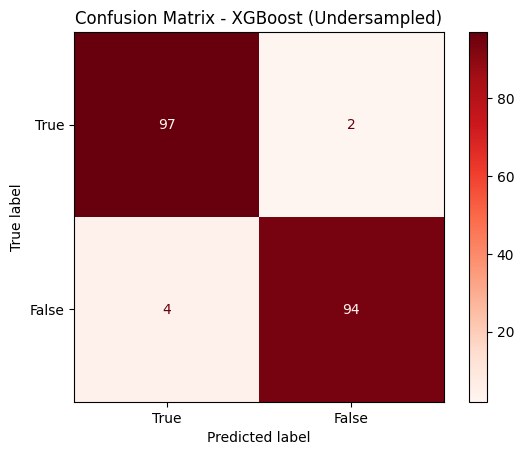

In [13]:
# ==============================================
# CONFUSION MATRIX - XGBOOST (UNDERSAMPLED)
# ==============================================

# --- Imports ---
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from imblearn.under_sampling import RandomUnderSampler

# --- Load Dataset ---
df = pd.read_csv('creditcard.csv')

# --- Prepare Data ---
X = df.drop('Class', axis=1)
y = df['Class']

# --- Scale Data ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Undersample Data ---
rus = RandomUnderSampler(random_state=42)
X_res, y_res = rus.fit_resample(X_scaled, y)
print(f"✅ Data after undersampling: {y_res.value_counts().to_dict()}")

# --- Train-Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res
)

# --- Train XGBoost Model ---
model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    n_estimators=150,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

# --- Predictions ---
y_pred = model.predict(X_test)

# --- Confusion Matrix ---
conf_matrix = confusion_matrix(y_test, y_pred)
vis = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=[True, False])
vis.plot(cmap='Reds')
plt.title('Confusion Matrix - XGBoost (Undersampled)')
plt.grid(False)
plt.show()


✅ Data after undersampling: {0: 492, 1: 492}


<Figure size 600x500 with 0 Axes>

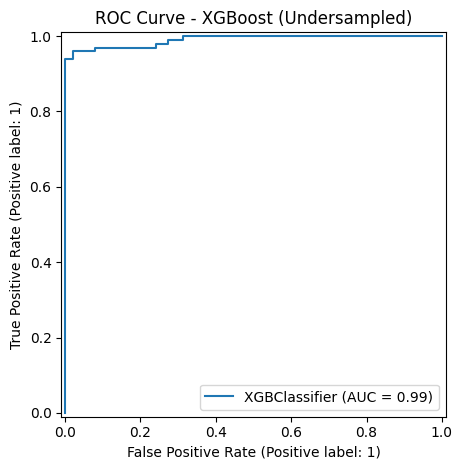

In [14]:
# ==============================================
# ROC CURVE - XGBOOST (UNDERSAMPLED)
# ==============================================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import RocCurveDisplay
from imblearn.under_sampling import RandomUnderSampler

# --- Load Dataset ---
df = pd.read_csv('creditcard.csv')

# --- Prepare Data ---
X = df.drop('Class', axis=1)
y = df['Class']

# --- Scale Data ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Undersample Data ---
rus = RandomUnderSampler(random_state=42)
X_res, y_res = rus.fit_resample(X_scaled, y)
print(f"✅ Data after undersampling: {y_res.value_counts().to_dict()}")

# --- Train-Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res
)

# --- Train XGBoost Model ---
model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    n_estimators=150,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

# --- Plot ROC Curve ---
plt.figure(figsize=(6,5))
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title('ROC Curve - XGBoost (Undersampled)')
plt.tight_layout()
plt.show()


✅ Data after undersampling: {0: 492, 1: 492}


<Figure size 600x500 with 0 Axes>

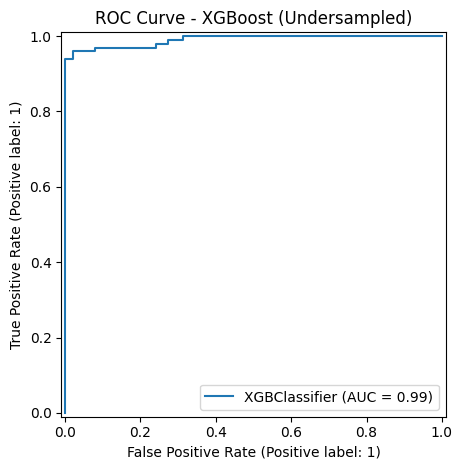

In [15]:
# ==============================================
# ROC CURVE - XGBOOST (UNDERSAMPLED)
# ==============================================

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import RocCurveDisplay
from imblearn.under_sampling import RandomUnderSampler

# --- Load Dataset ---
df = pd.read_csv('creditcard.csv')

# --- Prepare Data ---
X = df.drop('Class', axis=1)
y = df['Class']

# --- Scale Data ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Undersample Data ---
rus = RandomUnderSampler(random_state=42)
X_res, y_res = rus.fit_resample(X_scaled, y)
print(f"✅ Data after undersampling: {y_res.value_counts().to_dict()}")

# --- Train-Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res
)

# --- Train XGBoost Model ---
model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    n_estimators=150,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

# --- Plot ROC Curve ---
plt.figure(figsize=(6,5))
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title('ROC Curve - XGBoost (Undersampled)')
plt.tight_layout()
plt.show()
